In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'data\raw\dataset_maestro.csv')

df.head()

df['tipo_propiedad'].value_counts()

df.columns.tolist()

# df.isna().sum()

# df[df.operacion == 'alquiler'].groupby('barrio')['barrio'].value_counts().sort_values()

# df[(df.barrio == 'versalles') & (df.operacion == 'alquiler')].ambientes

df[df.ambientes == 1].groupby(['precio_moneda','operacion']).precio_valor.median()

df[(df.precio_moneda == 'ARS') & (df.operacion == 'venta')]

df[df.operacion == 'alquiler'].groupby(['barrio','precio_moneda'])['precio_valor'].median()

barrio            precio_moneda
agronomia         ARS              800000.0
                  USD                5500.0
almagro           ARS              700000.0
                  USD                1050.0
balvanera         ARS              595000.0
                                     ...   
villa santa rita  ARS              800000.0
                  USD                3000.0
villa soldati     ARS              650000.0
villa urquiza     ARS              895000.0
                  USD                3000.0
Name: precio_valor, Length: 86, dtype: float64

In [34]:
df[(df.operacion == 'alquiler') & (df.barrio == 'agronomia')]

,portal,id_aviso,url,fecha_scraping,operacion,tipo_propiedad,precio_valor,precio_moneda,precio_texto,expensas_valor,...,luminoso,balcon,a_reciclar,reciclado,credito_uva,frente,amoblado,patio_jardin,ascensor,profesional_renta
264,remax,5900fabf-8966-46bf-ba1a-e98fc4a637b6,https://www.remax.com.ar/listings/departamento...,2026-08-13T22:41:33+00:00,alquiler,departamento_estandar,800000.0,ARS,ARS 800000.0,74000.0,...,0,0,0,0,0,0,0,0,0,0
1542,remax,e8821a9b-b0b7-43ea-a846-4076b9a24bfb,https://www.remax.com.ar/listings/alquiler-loc...,2026-08-13T22:31:53+00:00,alquiler,local,5500.0,USD,USD 5500.0,NaN,...,0,0,0,0,0,0,0,0,0,0


In [35]:
df.tipo_propiedad.value_counts()

tipo_propiedad
departamento_estandar        7786
ph                           1529
departamento_monoambiente    1420
casa                          686
cochera                       524
oficina                       519
local                         501
departamento_semipiso         492
terrenos_y_lotes              409
departamento_duplex           271
departamento_piso             247
deposito                       90
departamento_loft              61
galpon                         58
casa_triplex                   48
casa_duplex                    46
edificio                       45
departamento_triplex           37
consultorio                    34
departamento_penthouse         22
fondo_de_comercio              20
hotel                          18
otros                           3
Name: count, dtype: int64

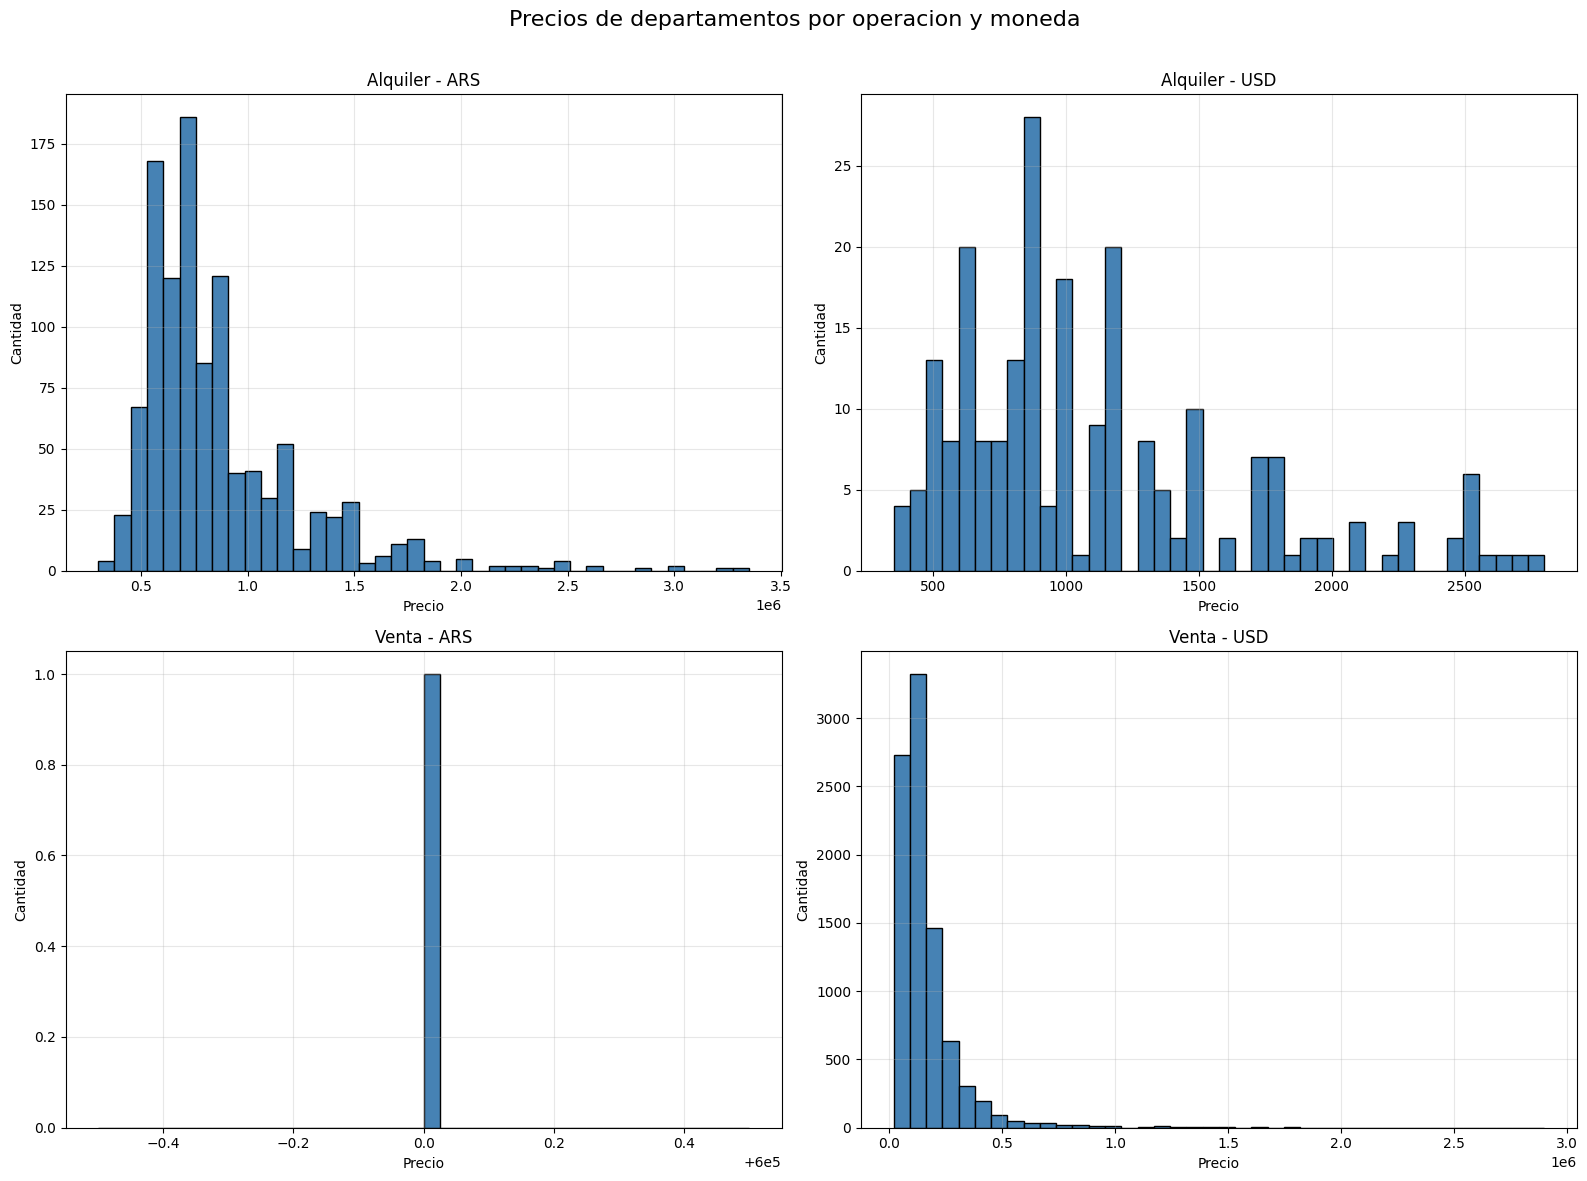

In [44]:
import matplotlib.pyplot as plt

deptos = df[df['tipo_propiedad'].str.contains('departamento', case=False, na=False)].copy()
deptos = deptos[deptos['precio_valor'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Precios de departamentos por operacion y moneda', fontsize=16)

config = [
    ('alquiler', 'ARS', axes[0, 0]),
    ('alquiler', 'USD', axes[0, 1]),
    ('venta', 'ARS', axes[1, 0]),
    ('venta', 'USD', axes[1, 1]),
]

for operacion, moneda, ax in config:
    subset = deptos[
        (deptos['operacion'] == operacion) &
        (deptos['precio_moneda'] == moneda)
    ].copy()

    precios = subset['precio_valor'].dropna()

    # Quitar outliers solo del histograma de alquiler en USD
    if (operacion == 'alquiler') and (moneda == 'USD') and not precios.empty:
        q1 = precios.quantile(0.25)
        q3 = precios.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        precios = precios[(precios >= lower_bound) & (precios <= upper_bound)]

    if precios.empty:
        ax.text(0.5, 0.5, f'Sin datos\n{operacion} / {moneda}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    ax.hist(precios, bins=40, color='steelblue', edgecolor='black')
    ax.set_title(f'{operacion.title()} - {moneda}')
    ax.set_xlabel('Precio')
    ax.set_ylabel('Cantidad')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
